In [4]:
# Step 1 — Import libraries
# This imports the tools needed for data analysis, visualization, preprocessing, modeling, and evaluation.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix,
    classification_report, roc_curve, precision_recall_curve
)

import warnings
warnings.filterwarnings("ignore")

In [5]:
# Step 2 — Load the dataset
# The file uses ; as separator, so we use sep=";".

file_path = "/Users/mebenga/Quantic MSBA/7-MSBA Analytics Methods and Frameworks/Analytics Methods and Frameworks _Project/bank+marketing/bank-additional/bank-additional-full.csv"  # adjust path if needed

df = pd.read_csv(file_path, sep=";")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [6]:
# Step 3 — Profile the dataset
# This checks data types, summary statistics, missing values, duplicates, and target distribution.

df.info()

df.describe()

df.isnull().sum()

df.duplicated().sum()

df["y"].value_counts(normalize=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

y
no     0.887346
yes    0.112654
Name: proportion, dtype: float64

In [7]:
# Step 4 — Clean the data
# I remove duplicates and convert the target into a binary variable.

df = df.drop_duplicates()

df["target"] = df["y"].map({"yes": 1, "no": 0})

df = df.drop(columns=["y"])

df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,target
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0


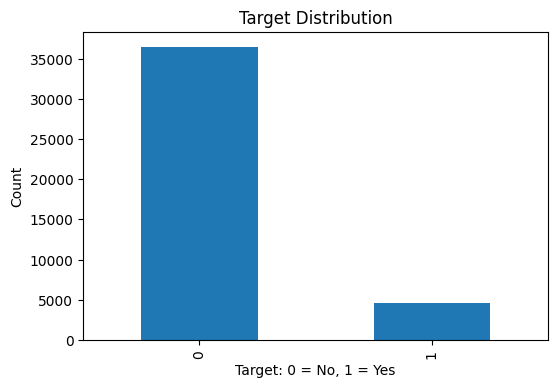

In [8]:
# Step 5 — Target distribution visualization
# This shows the class imbalance.

plt.figure(figsize=(6, 4))
df["target"].value_counts().plot(kind="bar")
plt.title("Target Distribution")
plt.xlabel("Target: 0 = No, 1 = Yes")
plt.ylabel("Count")
plt.show()


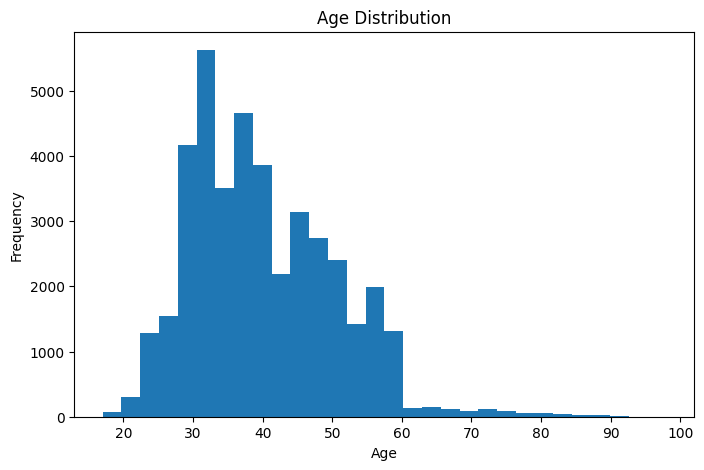

In [9]:
# Step 6 — Age distribution
# This helps understand the customer age profile.

plt.figure(figsize=(8, 5))
plt.hist(df["age"], bins=30)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

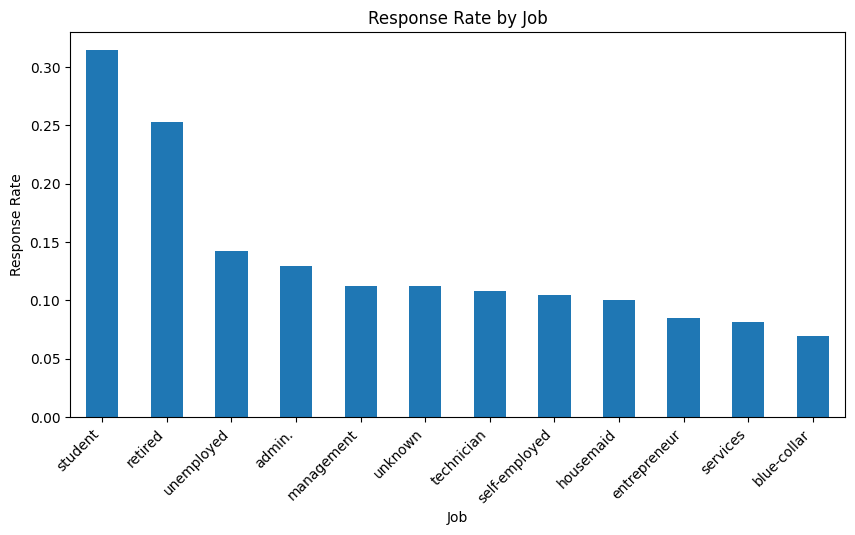

In [10]:
# Step 7 — Response rate by job
# This shows which job categories respond more positively.

job_response = df.groupby("job")["target"].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
job_response.plot(kind="bar")
plt.title("Response Rate by Job")
plt.xlabel("Job")
plt.ylabel("Response Rate")
plt.xticks(rotation=45, ha="right")
plt.show()

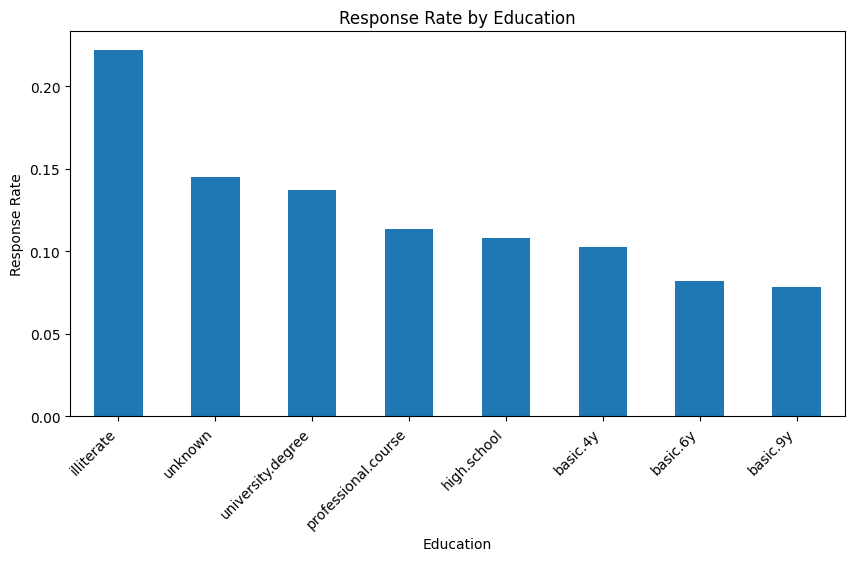

In [11]:
# Step 8 — Response rate by education
# This checks whether education level is associated with customer response.

education_response = df.groupby("education")["target"].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
education_response.plot(kind="bar")
plt.title("Response Rate by Education")
plt.xlabel("Education")
plt.ylabel("Response Rate")
plt.xticks(rotation=45, ha="right")
plt.show()

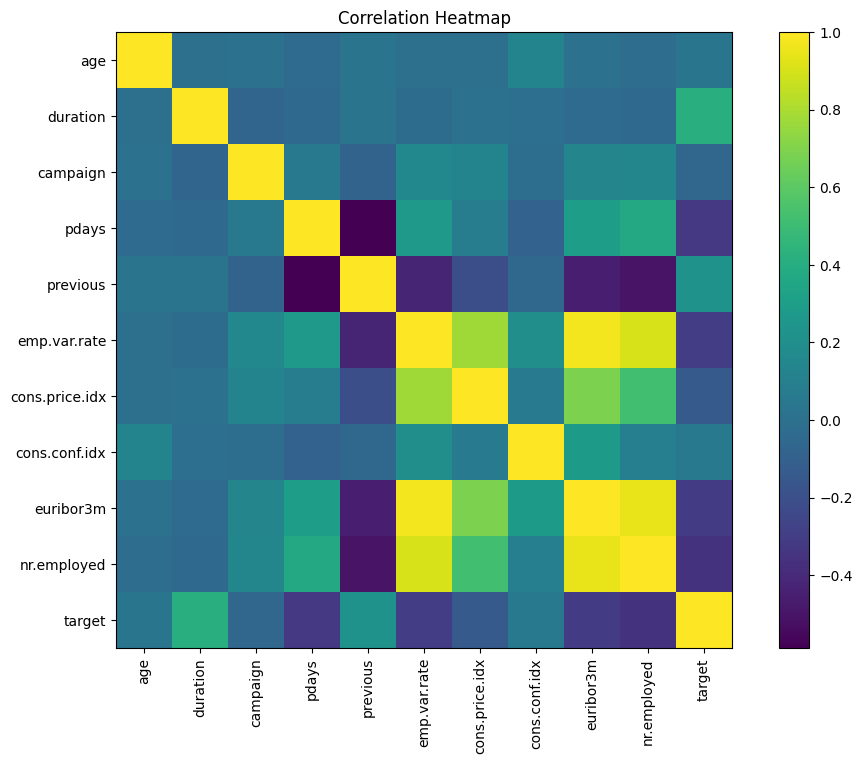

In [13]:
# Step 9 — Correlation heatmap
# This heatmap shows relationships between numerical variables.


numeric_df = df.select_dtypes(include=["int64", "float64"])

corr_matrix = numeric_df.corr()

plt.figure(figsize=(12, 8))
plt.imshow(corr_matrix)
plt.colorbar()

plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

plt.title("Correlation Heatmap")
plt.show()

In [14]:
# Step 10 — Prepare features and target
# We remove duration because it creates data leakage. It is known after the call, not before the retention decision.

X = df.drop(columns=["target", "duration"])
y = df["target"]

categorical_features = X.select_dtypes(include="object").columns.tolist()
numerical_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical features:", categorical_features)
print("Numerical features:", numerical_features)

Categorical features: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']
Numerical features: ['age', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']


In [15]:
# Step 11 — Train/test split
# stratify=y keeps the same target distribution in train and test sets.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

Training set: (28823, 19)
Testing set: (12353, 19)
target
0    0.887347
1    0.112653
Name: proportion, dtype: float64
target
0    0.887315
1    0.112685
Name: proportion, dtype: float64


In [17]:
# Step 12 — Preprocessing
# Numerical variables are scaled. Categorical variables are converted into dummy variables using one-hot encoding.

numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [18]:
# Step 13 — Logistic regression baseline
# Logistic regression is a good baseline because it is simple and easy to explain.

log_reg_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

log_reg_model.fit(X_train, y_train)

log_pred = log_reg_model.predict(X_test)
log_proba = log_reg_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, log_pred))

              precision    recall  f1-score   support

           0       0.95      0.85      0.90     10961
           1       0.36      0.65      0.46      1392

    accuracy                           0.83     12353
   macro avg       0.66      0.75      0.68     12353
weighted avg       0.88      0.83      0.85     12353



In [19]:
# Step 14 — Random Forest improved model
# Random Forest is the improved model because it can capture non-linear relationships.

rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        max_depth=12,
        min_samples_leaf=20,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.95      0.88      0.91     10961
           1       0.40      0.64      0.49      1392

    accuracy                           0.85     12353
   macro avg       0.68      0.76      0.70     12353
weighted avg       0.89      0.85      0.87     12353



In [20]:
# Step 15 — Compare models
# This table compares baseline and improved model performance.

results_table = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Accuracy": accuracy_score(y_test, log_pred),
        "Precision": precision_score(y_test, log_pred),
        "Recall": recall_score(y_test, log_pred),
        "F1": f1_score(y_test, log_pred),
        "ROC_AUC": roc_auc_score(y_test, log_proba),
        "PR_AUC": average_precision_score(y_test, log_proba)
    },
    {
        "Model": "Random Forest",
        "Accuracy": accuracy_score(y_test, rf_pred),
        "Precision": precision_score(y_test, rf_pred),
        "Recall": recall_score(y_test, rf_pred),
        "F1": f1_score(y_test, rf_pred),
        "ROC_AUC": roc_auc_score(y_test, rf_proba),
        "PR_AUC": average_precision_score(y_test, rf_proba)
    }
])

results_table.round(3)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Logistic Regression,0.831,0.361,0.647,0.464,0.803,0.449
1,Random Forest,0.851,0.400,0.639,0.492,0.814,0.483


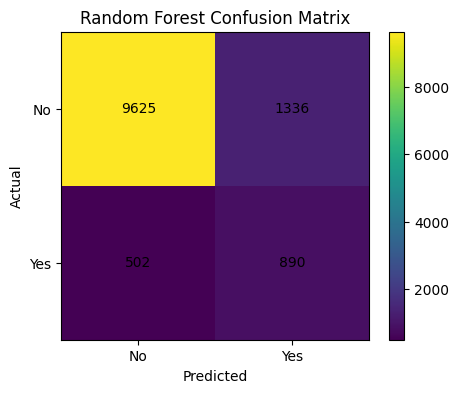

In [21]:
# Step 16 — Confusion matrix
# This shows true positives, false positives, true negatives, and false negatives.

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.colorbar()

plt.xticks([0, 1], ["No", "Yes"])
plt.yticks([0, 1], ["No", "Yes"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

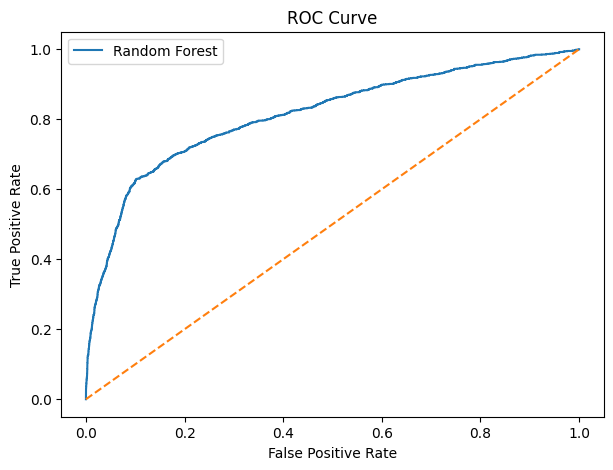

In [22]:
# Step 17 — ROC curve
# The ROC curve shows how well the model separates positive and negative cases.

fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_proba)

plt.figure(figsize=(7, 5))
plt.plot(fpr_rf, tpr_rf, label="Random Forest")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

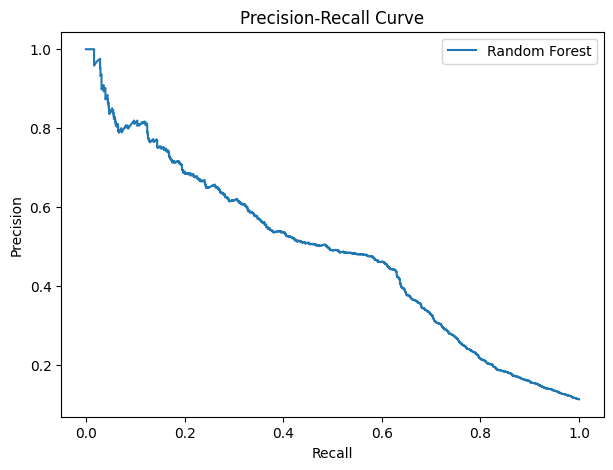

In [23]:
# Step 18 — Precision-recall curve
# This is especially useful because the target class is imbalanced.

precision_rf, recall_rf, _ = precision_recall_curve(y_test, rf_proba)

plt.figure(figsize=(7, 5))
plt.plot(recall_rf, precision_rf, label="Random Forest")

plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.show()

In [24]:
# Step 19 — Threshold analysis
# This helps executives select a practical cutoff for action.

thresholds = np.arange(0.10, 0.91, 0.05)

rows = []

for threshold in thresholds:
    preds = (rf_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()

    rows.append({
        "Threshold": threshold,
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "TN": tn,
        "Precision": precision_score(y_test, preds, zero_division=0),
        "Recall": recall_score(y_test, preds, zero_division=0),
        "F1": f1_score(y_test, preds, zero_division=0),
        "Targeted_Customers": preds.sum(),
        "Targeted_Rate": preds.mean()
    })

threshold_results = pd.DataFrame(rows)

threshold_results.round(3)

,Threshold,TP,FP,FN,TN,Precision,Recall,F1,Targeted_Customers,Targeted_Rate
0,0.10,1392,10961,0,0,0.113,1.000,0.203,12353,1.000
1,0.15,1385,10761,7,200,0.114,0.995,0.205,12146,0.983
2,0.20,1342,9224,50,1737,0.127,0.964,0.224,10566,0.855
3,0.25,1278,7294,114,3667,0.149,0.918,0.257,8572,0.694
4,0.30,1190,5400,202,5561,0.181,0.855,0.298,6590,0.533
5,0.35,1073,3310,319,7651,0.245,0.771,0.372,4383,0.355
6,0.40,981,2113,411,8848,0.317,0.705,0.437,3094,0.250
7,0.45,931,1637,461,9324,0.363,0.669,0.470,2568,0.208
8,0.50,890,1336,502,9625,0.400,0.639,0.492,2226,0.180
9,0.55,877,1150,515,9811,0.433,0.630,0.513,2027,0.164


In [25]:
# Step 20 — Decision rule

recommended_threshold = 0.36

final_pred = (rf_proba >= recommended_threshold).astype(int)

print(classification_report(y_test, final_pred))

cm = confusion_matrix(y_test, final_pred)
print(cm)

              precision    recall  f1-score   support

           0       0.96      0.73      0.83     10961
           1       0.26      0.76      0.39      1392

    accuracy                           0.73     12353
   macro avg       0.61      0.74      0.61     12353
weighted avg       0.88      0.73      0.78     12353

[[8009 2952]
 [ 341 1051]]


In [26]:
# Business decision rule:

test_customers = X_test.copy()
test_customers["actual"] = y_test.values
test_customers["risk_score"] = rf_proba

test_customers["priority"] = pd.cut(
    test_customers["risk_score"],
    bins=[0, 0.36, 0.50, 1],
    labels=["Low priority", "Medium priority", "High priority"],
    include_lowest=True
)

test_customers[["risk_score", "priority", "actual"]].head()

,risk_score,priority,actual
12694,0.331424,Low priority,0
879,0.187308,Low priority,0
12340,0.224555,Low priority,0
5497,0.174369,Low priority,0
19257,0.335744,Low priority,0


In [29]:
# Interpretation:

# | Priority |     Score | Action                                     |
# | -------- | --------: | ------------------------------------------ |
# | Low      |    < 0.36 | No costly intervention                     |
# | Medium   | 0.36–0.49 | SMS/email/light offer                      |
# | High     |    ≥ 0.50 | Call center + personalized retention offer |


In [30]:
# Step 21 — Feature importance

feature_names_num = numerical_features

feature_names_cat = rf_model.named_steps["preprocessor"] \
    .named_transformers_["cat"] \
    .named_steps["encoder"] \
    .get_feature_names_out(categorical_features)

all_feature_names = np.concatenate([feature_names_num, feature_names_cat])

importances = rf_model.named_steps["classifier"].feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": all_feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

feature_importance_df.head(20)

,Feature,Importance
8,nr.employed,0.172941
7,euribor3m,0.169110
4,emp.var.rate,0.116937
6,cons.conf.idx,0.065147
2,pdays,0.057554
5,cons.price.idx,0.055590
61,poutcome_success,0.045697
0,age,0.034788
43,contact_telephone,0.024060
50,month_may,0.022895


<Figure size 1000x600 with 0 Axes>

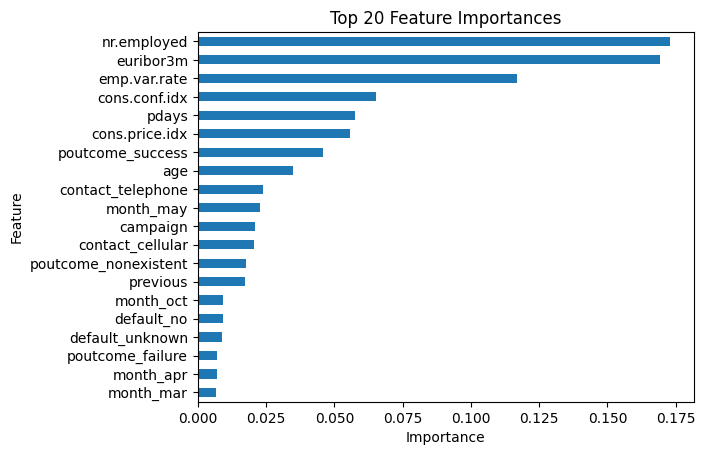

In [31]:
# Visualize feature importance:
# This explains which variables influence the Random Forest model most.

plt.figure(figsize=(10, 6))

feature_importance_df.head(20).sort_values("Importance").plot(
    kind="barh",
    x="Feature",
    y="Importance",
    legend=False
)

plt.title("Top 20 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [32]:
#Step 22 — Export outputs

results_table.to_csv("novabank_model_results.csv", index=False)
threshold_results.to_csv("novabank_threshold_analysis.csv", index=False)
feature_importance_df.to_csv("novabank_feature_importance.csv", index=False)

print("Outputs exported successfully.")

Outputs exported successfully.
